<a href="https://colab.research.google.com/github/fredericlu-portfolio/fredericlu-portfolio.github.io/blob/main/FredericLu_Credit%20Risk%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Upload Dataset : Credit risk analysis**

# GROUP NAMES : Frederic LU, Nour JEMAL, Mohammed Amine KHAFALLAH

In [ ]:
print("Hello World")

Hello World


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path_input="/content/drive/MyDrive/Colab Notebooks/DataCoSupplyChainDataset.csv"

In [ ]:
df=pd.read_csv(path_input, encoding='latin-1')
pd.set_option('display.max_columns',100)

## **Data Introduction**

In [ ]:
df.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
type(df)
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [ ]:
relevant_columns = ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Product Price']
df[relevant_columns].describe(percentiles=[.25, .50, .75, .95])

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,20.664741,0.101668,141.232550,0.120647,2.127638,203.772096,183.107609,21.974989,141.232550
std,1.623722,1.374449,104.433526,120.043670,21.800901,0.070415,139.732492,0.466796,1.453451,132.273077,120.043670,104.433526,139.732492
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,0.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.979980,9.990000
25%,2.000000,2.000000,7.000000,104.379997,5.400000,0.040000,50.000000,0.080000,1.000000,119.980003,104.379997,7.000000,50.000000
50%,3.000000,4.000000,31.520000,163.990005,14.000000,0.100000,59.990002,0.270000,1.000000,199.919998,163.990005,31.520000,59.990002
75%,5.000000,4.000000,64.800003,247.399994,29.990000,0.160000,199.990005,0.360000,3.000000,299.950012,247.399994,64.800003,199.990005
95%,6.000000,4.000000,132.289993,383.980011,62.500000,0.250000,399.980011,0.480000,5.000000,399.980011,383.980011,132.289993,399.980011
max,6.000000,4.000000,911.799988,1939.989990,500.000000,0.250000,1999.989990,0.500000,5.000000,1999.989990,1939.989990,911.799988,1999.989990


In [ ]:
# Analyser la relation entre le Taux de Remise et le Ratio de Profit Moyen
discount_profit_analysis = df.groupby('Order Item Discount Rate').agg(
    Avg_Profit_Ratio=('Order Item Profit Ratio', 'mean'),
    Std_Benefit=('Benefit per order', 'std') # Tester l'écart-type ici
).sort_values(by='Avg_Profit_Ratio', ascending=True)

print("\n--- Écart-type du Bénéfice par Taux de Remise ---")
print(discount_profit_analysis.to_markdown(numalign="left", stralign="left"))


--- Écart-type du Bénéfice par Taux de Remise ---
| Order Item Discount Rate   | Avg_Profit_Ratio   | Std_Benefit   |
|:---------------------------|:-------------------|:--------------|
| 0.03                       | 0.110835           | 113.918       |
| 0.2                        | 0.112289           | 98.4925       |
| 0.17                       | 0.114162           | 96.1122       |
| 0.15                       | 0.116291           | 96.3953       |
| 0.13                       | 0.117777           | 96.8237       |
| 0.16                       | 0.119285           | 97.8318       |
| 0.1                        | 0.119368           | 110.296       |
| 0.12                       | 0.119627           | 105.465       |
| 0.01                       | 0.121483           | 112.487       |
| 0.18                       | 0.121893           | 93.5569       |
| 0.02                       | 0.122657           | 113.726       |
| 0.09                       | 0.122824           | 108.093      

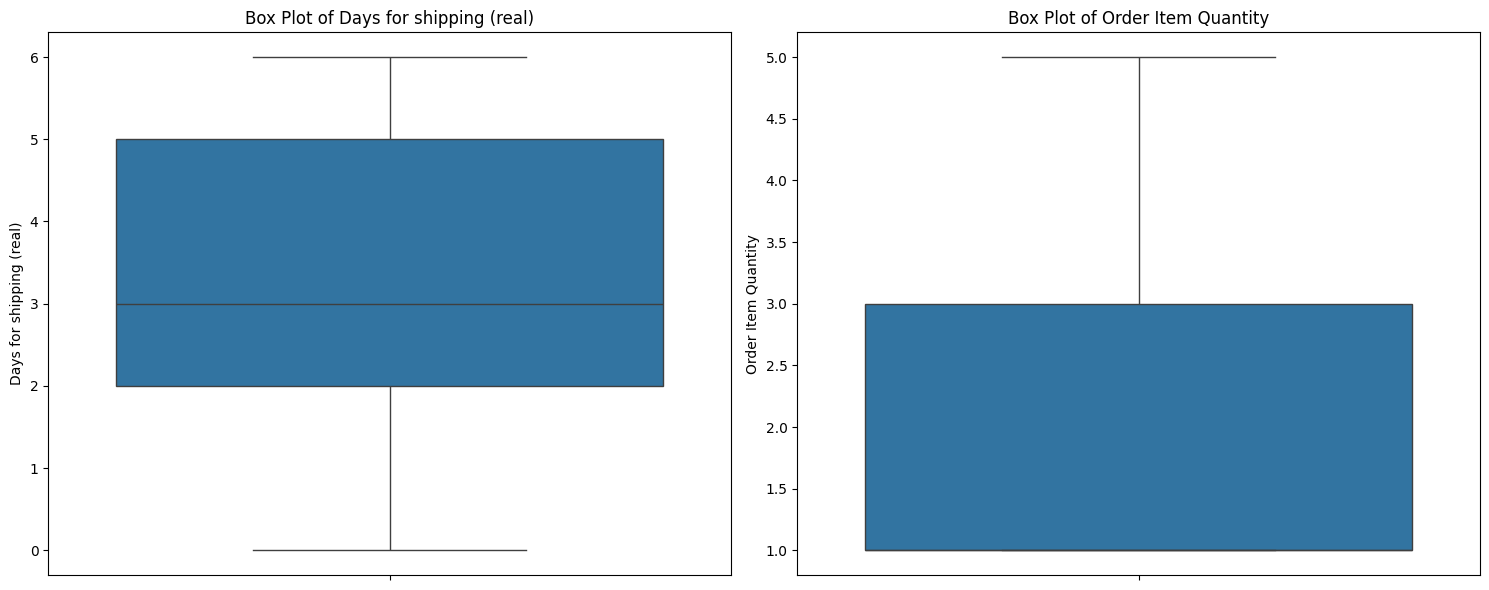

Box plots generated for 'Days for shipping (real)' and 'Order Item Quantity'.


In [ ]:
# List of columns for which to create box plots
columns_to_plot = ['Days for shipping (real)', 'Order Item Quantity']

plt.figure(figsize=(15, 6))

for i, column in enumerate(columns_to_plot):
    plt.subplot(1, len(columns_to_plot), i + 1) # Create a subplot for each column
    sns.boxplot(y=df[column])
    plt.title(f'Box Plot of {column}')
    plt.ylabel(column)

plt.tight_layout()
plt.show()

print("Box plots generated for 'Days for shipping (real)' and 'Order Item Quantity'.")


In [ ]:
missing_data_summary = pd.DataFrame({
    'Total Missing': df.isnull().sum(),
    'Percentage Missing': (df.isnull().sum() / len(df)) * 100
  })

missing_data_relevant = missing_data_summary[missing_data_summary['Total Missing']>0].sort_values(by='Percentage Missing', ascending=False)

print(missing_data_relevant.to_markdown(numalign="left", stralign="left"))

|                     | Total Missing   | Percentage Missing   |
|:--------------------|:----------------|:---------------------|
| Product Description | 180519          | 100                  |
| Order Zipcode       | 155679          | 86.2397              |
| Customer Lname      | 8               | 0.00443167           |
| Customer Zipcode    | 3               | 0.00166187           |


## **Core analysis**



--- TOP 20: FREQUENCY OF LOSSES BY PRODUCT CATEGORY ---
| Category Name        | Total_Transactions   | Loss_Count   | Avg_Benefit_Per_Order   | Loss_Rate_Percent   |
|:---------------------|:---------------------|:-------------|:------------------------|:--------------------|
| Men's Clothing       | 208                  | 52           | 9.64442                 | 25                  |
| Health and Beauty    | 362                  | 86           | 26.2255                 | 23.7569             |
| Video Games          | 838                  | 192          | 3.24286                 | 22.9117             |
| Golf Shoes           | 524                  | 117          | 23.6757                 | 22.3282             |
| DVDs                 | 483                  | 107          | 13.7794                 | 22.1532             |
| As Seen on  TV!      | 68                   | 15           | 10.5063                 | 22.0588             |
| Pet Supplies         | 492                  | 106     

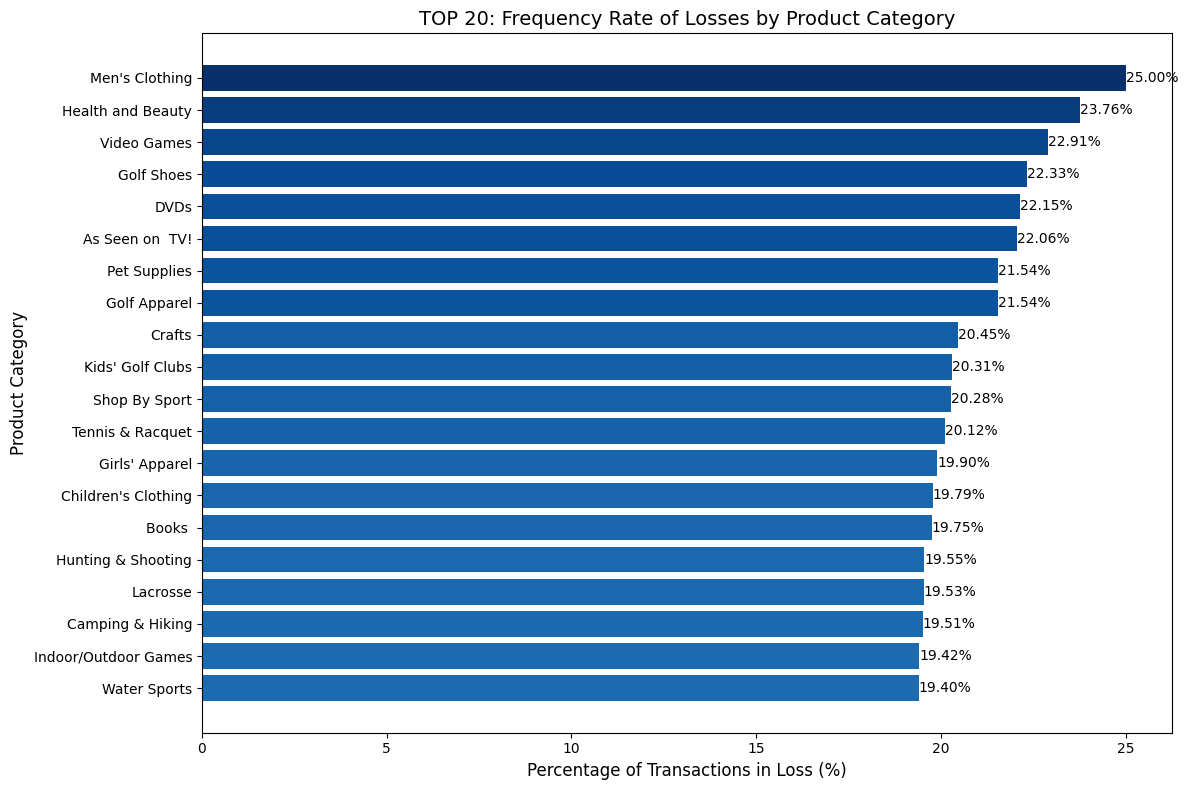

In [ ]:
# --- 1. TRANSACTION CLASSIFICATION ---

# Create a binary variable: 1 if Loss (Benefit <= 0), 0 if Profit (Benefit > 0)
# We use the 'Benefit per order' column.
df['Loss_Flag'] = np.where(df['Benefit per order'] <= 0, 1, 0)


# --- 2. AGGREGATION AND RATE CALCULATION ---

loss_analysis = df.groupby('Category Name').agg(
    Total_Transactions=('Order Id', 'count'),
    Loss_Count=('Loss_Flag', 'sum'),
    Avg_Benefit_Per_Order=('Benefit per order', 'mean')
).reset_index()

# Calculate the Loss Rate (%)
loss_analysis['Loss_Rate_Percent'] = (
    loss_analysis['Loss_Count'] / loss_analysis['Total_Transactions']
) * 100

# Sort by the highest Loss Rate to identify the problems
loss_analysis = loss_analysis.sort_values(by='Loss_Rate_Percent', ascending=False)

# --- NEW: SELECT THE TOP 20 MOST RISKY CATEGORIES ---
loss_analysis_top20 = loss_analysis.head(20)


# --- 3. DISPLAY TABLE AND GRAPH ---

print("--- TOP 20: FREQUENCY OF LOSSES BY PRODUCT CATEGORY ---")
print(loss_analysis_top20.to_markdown(index=False, numalign="left", stralign="left"))


# Create the Bar Chart (Loss Rate)
plt.figure(figsize=(12, 8)) # Enlargement for the Top 20

# Use the filtered DataFrame for the chart
# Create colors (using blue for visual clarity)
colors = plt.cm.Blues(loss_analysis_top20['Loss_Rate_Percent'] / loss_analysis_top20['Loss_Rate_Percent'].max())

plt.barh(loss_analysis_top20['Category Name'], loss_analysis_top20['Loss_Rate_Percent'], color=colors)

# Titles and labels
plt.title('TOP 20: Frequency Rate of Losses by Product Category', fontsize=14)
plt.xlabel('Percentage of Transactions in Loss (%)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

# Annotation for the bars
for index, value in enumerate(loss_analysis_top20['Loss_Rate_Percent']):
    plt.text(value, index, f'{value:.2f}%', va='center')

plt.gca().invert_yaxis() # Puts the riskiest at the top
plt.tight_layout()
plt.show()

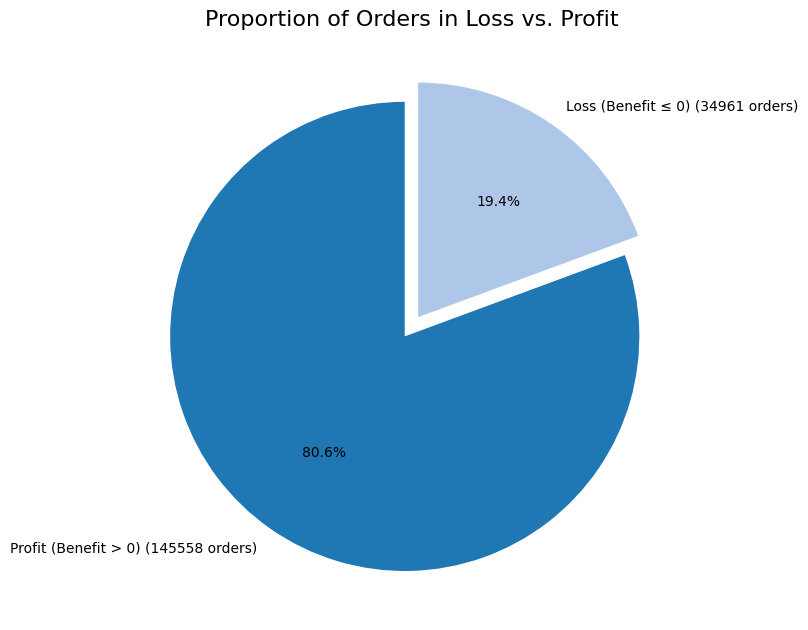

In [ ]:
# --- 1. TRANSACTION CLASSIFICATION ---

# Create a binary variable: 1 if Loss (Benefit <= 0), 0 if Profit (Benefit > 0)
df['Loss_Flag'] = np.where(df['Benefit per order'] <= 0, 1, 0)


# --- 2. AGGREGATION AND FORMATTING FOR THE CHART ---

# Count the number of orders in Profit and Loss
loss_counts = df['Loss_Flag'].value_counts().reset_index()
loss_counts.columns = ['Loss_Flag', 'Count']

# Map binary values to clear labels (English translation)
loss_counts['Label'] = loss_counts['Loss_Flag'].map({1: 'Loss (Benefit ≤ 0)', 0: 'Profit (Benefit > 0)'})

# Calculate the percentage for the Pie Chart labels
total_count = loss_counts['Count'].sum()
loss_counts['Percentage'] = (loss_counts['Count'] / total_count) * 100


# --- 3. CREATING THE PIE CHART ---

plt.figure(figsize=(8, 8))

# Define data and colors
sizes = loss_counts['Count']
# Adjust labels to include the count and use English text
labels = loss_counts.apply(lambda x: f"{x['Label']} ({x['Count']} orders)", axis=1)
# Use two shades of blue for consistency, or adjust as needed
colors = ['#1f77b4', '#aec7e8'] # Blue colors (Dark Blue for Profit, Light Blue for Loss)

# Create the Pie Chart
plt.pie(sizes,
        labels=labels,
        autopct='%1.1f%%', # Display percentage with one decimal
        startangle=90,
        colors=colors,
        explode=(0.05, 0.05) # Slightly separate the sections for better effect
       )

# Title
plt.title('Proportion of Orders in Loss vs. Profit', fontsize=16)

plt.tight_layout()
plt.show()

### Delivery Gap per Region

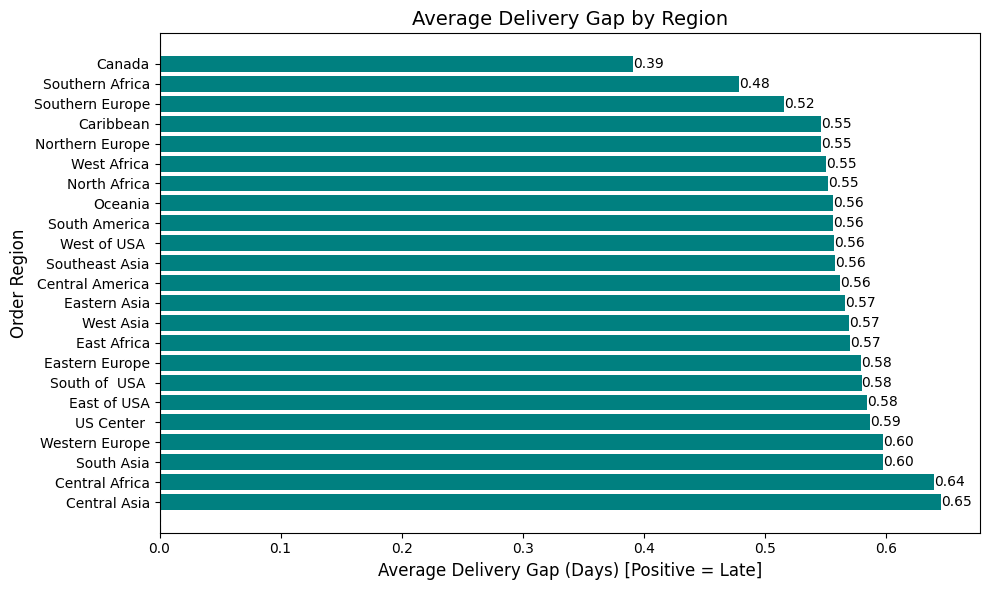

In [ ]:
# --- 1. Data Preparation ---

# Calculate the delivery gap
df['Delivery_Gap'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# Aggregate by region and calculate the average gap
region_performance = df.groupby('Order Region')['Delivery_Gap'].mean().sort_values(ascending=False)

# Create a DataFrame for visualization
region_df = region_performance.reset_index()


# --- 2. Create the Bar Chart ---

plt.figure(figsize=(10, 6))

# Determine colors (use a different color for positive delays)
colors = ['teal' if gap > 0 else 'green' for gap in region_df['Delivery_Gap']]

# Create the bar chart
plt.barh(region_df['Order Region'], region_df['Delivery_Gap'], color=colors)

# Add a zero reference line (the "on time" target)
plt.axvline(0, color='gray', linestyle='--', zorder=-1) # zorder to place behind bars

# Titles and labels
plt.title('Average Delivery Gap by Region', fontsize=14)
plt.xlabel('Average Delivery Gap (Days) [Positive = Late]', fontsize=12)
plt.ylabel('Order Region', fontsize=12)

# Annotation for bars (display exact values)
for index, value in enumerate(region_df['Delivery_Gap']):
    plt.text(value, index, f'{value:.2f}', va='center', ha='left' if value > 0 else 'right') # Adjust text alignment based on value

plt.tight_layout()
plt.savefig('ecart_livraison_par_region.png')
plt.show()

### Delivery Gap per shipping mode

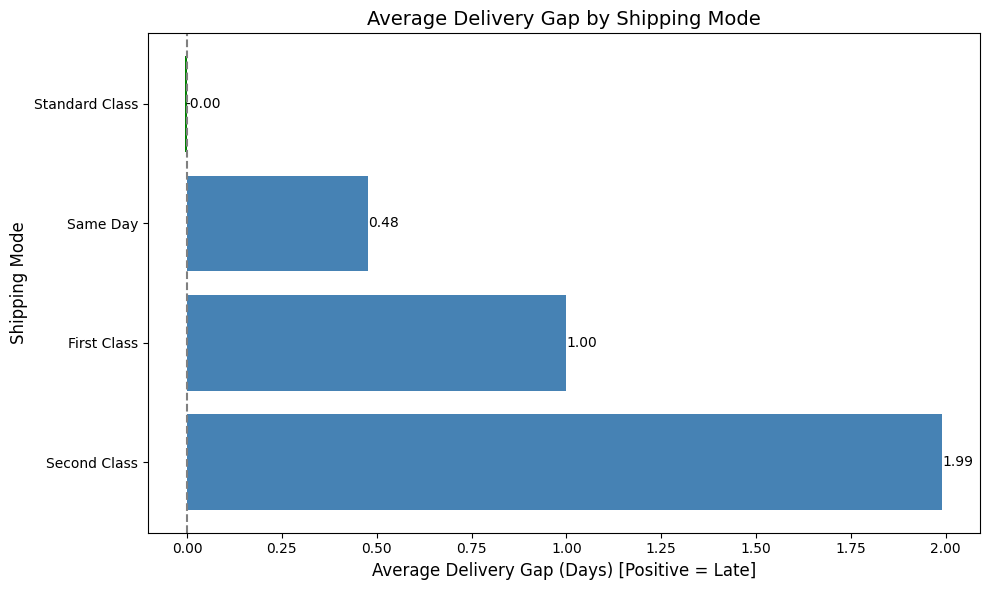

In [ ]:
# Calculate the delivery gap
df['Delivery_Gap'] = df['Days for shipping (real)'] - df['Days for shipment (scheduled)']

# Aggregate by shipping mode and calculate the average gap
shipping_mode_performance = df.groupby('Shipping Mode')['Delivery_Gap'].mean().sort_values(ascending=False)

# Create a DataFrame for visualization
mode_df = shipping_mode_performance.reset_index()

# Create the bar chart
plt.figure(figsize=(10, 6))
colors = ['steelblue' if gap > 0 else 'green' for gap in mode_df['Delivery_Gap']]
plt.barh(mode_df['Shipping Mode'], mode_df['Delivery_Gap'], color=colors)
plt.axvline(0, color='gray', linestyle='--')

# Titles and labels
plt.title('Average Delivery Gap by Shipping Mode', fontsize=14)
plt.xlabel('Average Delivery Gap (Days) [Positive = Late]', fontsize=12)
plt.ylabel('Shipping Mode', fontsize=12)

# Annotation for bars
for index, value in enumerate(mode_df['Delivery_Gap']):
    plt.text(value, index, f'{value:.2f}', va='center')

plt.tight_layout()
plt.savefig('ecart_livraison_par_mode.png')

### Average Benefit per by Products AND Average Sales per Product



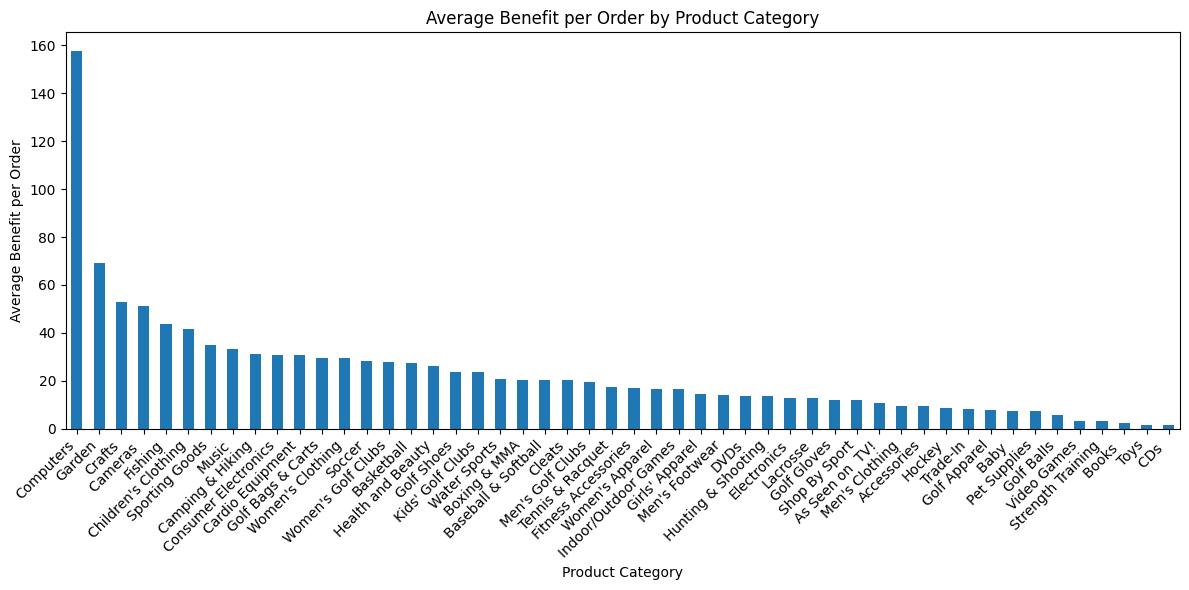

In [ ]:
# 1. Group by category and compute average benefit
avg_benefit = df.groupby("Category Name")["Benefit per order"].mean().sort_values(ascending=False)

# 2. Plot the bar chart
plt.figure(figsize=(12,6))
avg_benefit.plot(kind="bar")

# 3. Titles and labels
plt.title("Average Benefit per Order by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Benefit per Order")


# 4. Layout improvement
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Show the plot
plt.show()

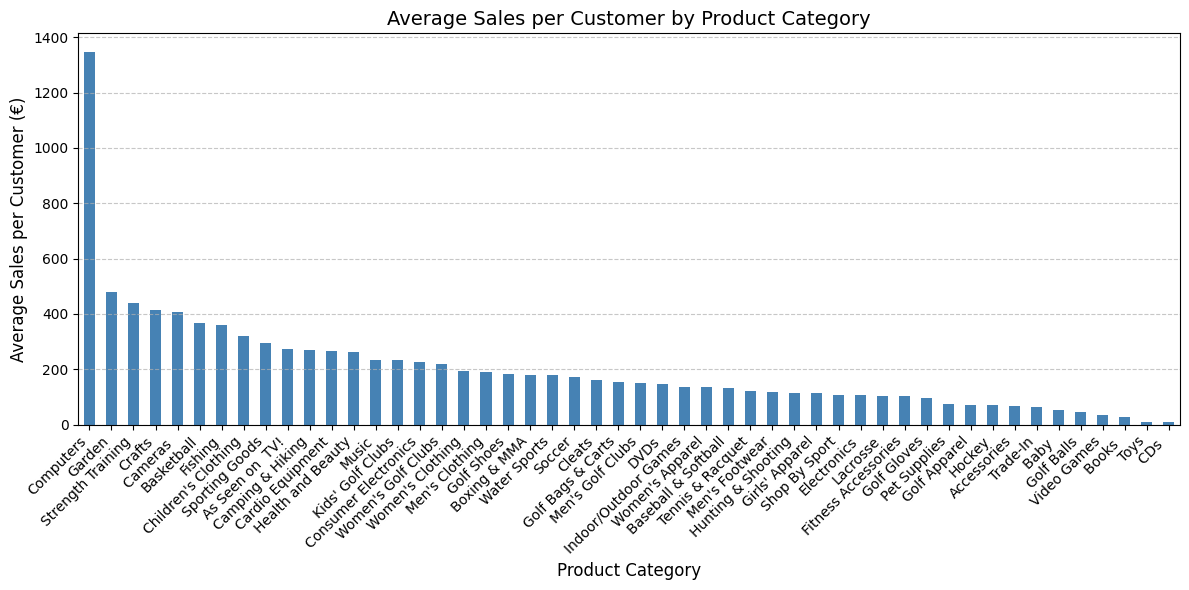

In [ ]:
# --- Sales Analysis by Product ---

# 1. Group by category and calculate the average sales per customer
# Use .mean() to get the average value of sales per order in this category
# If you wanted total sales, you would use .sum()
avg_sales_per_category = df.groupby('Category Name')['Sales per customer'].mean().sort_values(ascending=False)

# 2. Create the figure for the chart
plt.figure(figsize=(12,6))

# 3. Plot the bar chart
# Using the .plot(kind="bar") method
avg_sales_per_category.plot(kind='bar', color='steelblue') # Change color to distinguish from benefit

# 4. Titles and labels
plt.title('Average Sales per Customer by Product Category', fontsize=14)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Average Sales per Customer (€)', fontsize=12)

# 5. Layout improvement
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
plt.tight_layout()

# Show the plot
plt.show()

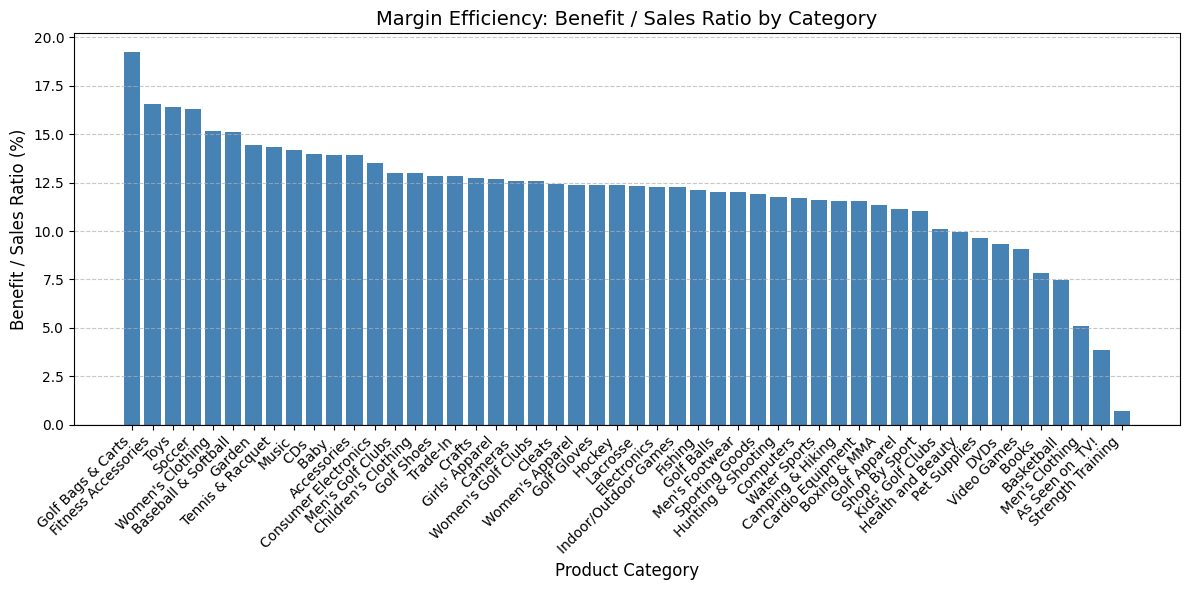


--- Margin Efficiency Table ---
| Category Name        | Total_Benefit   | Total_Sales   | Benefit_to_Sales_Ratio   |
|:---------------------|:----------------|:--------------|:-------------------------|
| Golf Bags & Carts    | 1810.07         | 9403.79       | 19.2483                  |
| Fitness Accessories  | 5258.39         | 31751.4       | 16.5611                  |
| Toys                 | 900.71          | 5485.68       | 16.4193                  |
| Soccer               | 3901.95         | 23909.9       | 16.3194                  |
| Women's Clothing     | 19102.8         | 126007        | 15.1602                  |
| Baseball & Softball  | 12762.1         | 84367.3       | 15.1269                  |
| Garden               | 33443           | 231765        | 14.4297                  |
| Tennis & Racquet     | 5747.98         | 40077.8       | 14.3421                  |
| Music                | 14436.3         | 101687        | 14.1968                  |
| CDs                

In [ ]:
# --- 1. Group and Calculate Total Benefit and Total Sales ---

# We group and SUM margin and total sales for greater accuracy.
# Note: The use of 'Sales per customer' here is a proxy for total revenue per category.
profit_sales_summary = df.groupby('Category Name').agg(
    Total_Benefit=('Benefit per order', 'sum'),
    Total_Sales=('Sales per customer', 'sum')
).reset_index()

# --- 2. Calculate Benefit / Sales Ratio ---

# Ratio = Total_Benefit / Total_Sales. Multiplied by 100 to get a percentage.
profit_sales_summary['Benefit_to_Sales_Ratio'] = (
    profit_sales_summary['Total_Benefit'] / profit_sales_summary['Total_Sales']
) * 100

# Sort to show the most efficient categories first
ratio_sorted = profit_sales_summary.sort_values(
    by='Benefit_to_Sales_Ratio', ascending=False
)

# --- 3. Create the Bar Chart for the Ratio ---

plt.figure(figsize=(12, 6))

# Create the chart
bars = plt.bar(ratio_sorted['Category Name'], ratio_sorted['Benefit_to_Sales_Ratio'],
               color=np.where(ratio_sorted['Benefit_to_Sales_Ratio'] > 0, 'steelblue', 'red'))

# 4. Titles and labels
plt.title('Margin Efficiency: Benefit / Sales Ratio by Category', fontsize=14)
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Benefit / Sales Ratio (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8) # 0% reference line

# Layout improvement
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Show the chart
plt.show()

# Display the data table for numerical interpretation
print('\n--- Margin Efficiency Table ---')
print(ratio_sorted.to_markdown(index=False, numalign='left', stralign='left'))

--- Generating Delivery Gap Visualization ---


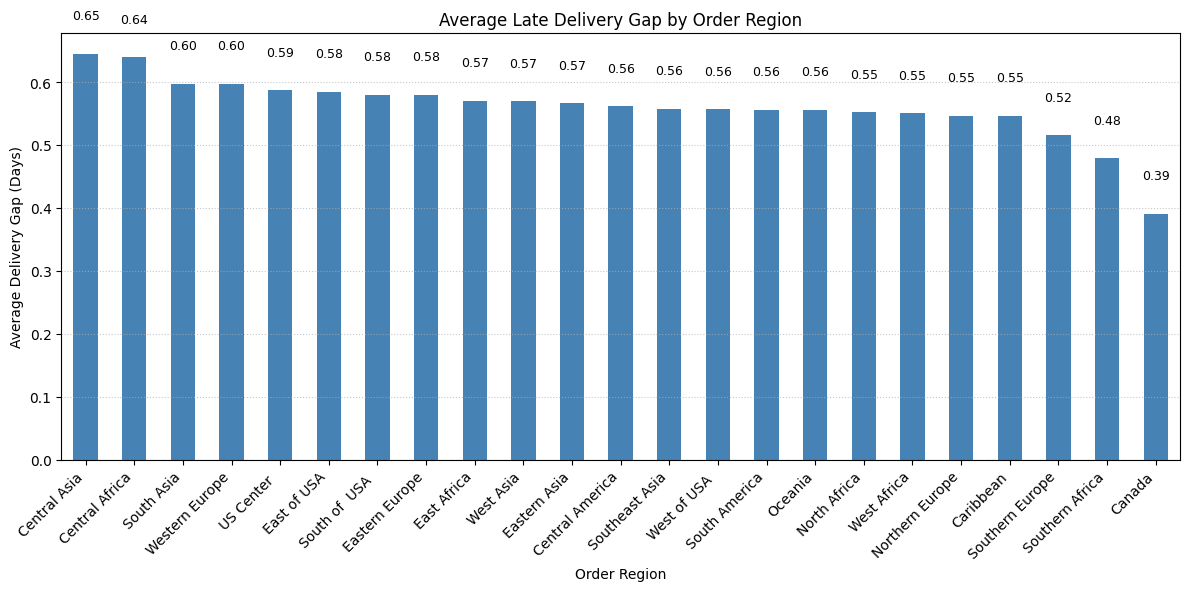


Visualization complete. The bar chart shows the average number of days difference
between the actual and scheduled shipping time for each region.


In [ ]:
# Define the key columns needed for the analysis
COLUMNS_OF_INTEREST = [
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Order Region'
]

df_analysis = df[COLUMNS_OF_INTEREST].copy()

# Ensure day columns are numeric and handle any missing values by dropping rows
for col in ['Days for shipping (real)', 'Days for shipment (scheduled)']:
    df_analysis[col] = pd.to_numeric(df_analysis[col], errors='coerce')

df_analysis.dropna(subset=['Days for shipping (real)', 'Days for shipment (scheduled)', 'Order Region'], inplace=True)


# --- 3. Calculate the Late Delivery Gap ---
# The gap is defined as the real days minus the scheduled days.
# A positive value means the delivery was late.
# A negative value means the delivery was early.
df_analysis['Delivery_Gap'] = df_analysis['Days for shipping (real)'] - df_analysis['Days for shipment (scheduled)']


# --- 4. Group Data for Visualization ---
# Calculate the average gap for each region
region_gap = df_analysis.groupby('Order Region')['Delivery_Gap'].mean().sort_values(ascending=False)


# --- 5. Visualize the Results (Bar Chart) ---
print("--- Generating Delivery Gap Visualization ---")

plt.figure(figsize=(12, 6))

# Determine color based on whether the average gap is positive (late) or negative (early)
colors = ['steelblue' if gap > 0 else 'seagreen' for gap in region_gap]

region_gap.plot(kind='bar', color=colors)

plt.title('Average Late Delivery Gap by Order Region')
plt.xlabel('Order Region')
plt.ylabel('Average Delivery Gap (Days)')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8) # Add a zero line for reference
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off

# Add data labels on top of the bars
for index, value in enumerate(region_gap):
    # Adjust position for visibility
    y_offset = 0.05 if value >= 0 else -0.1
    plt.text(index, value + y_offset, f'{value:.2f}', ha='center', va='bottom', fontsize=9)

plt.show()

print("\nVisualization complete. The bar chart shows the average number of days difference")
print("between the actual and scheduled shipping time for each region.")

### Late Delivery Risk per Product Categories

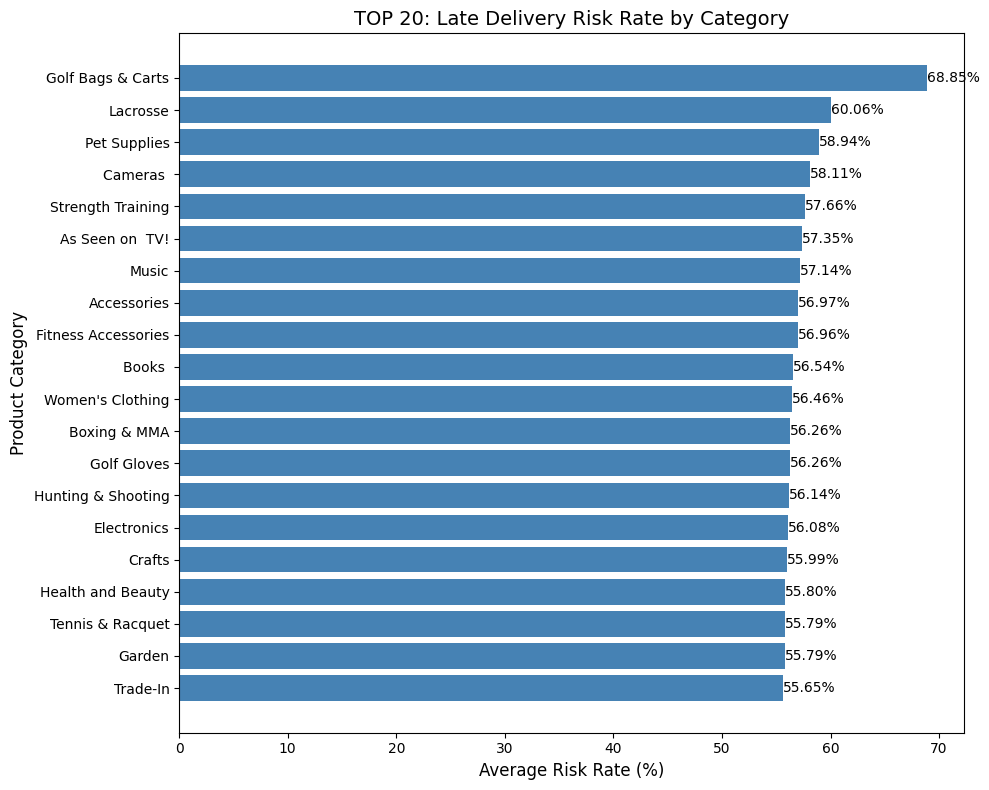

In [ ]:
# --- 1. Data Preparation ---

# Aggregate by product category and calculate the average risk rate (in %)
risk_by_product = df.groupby('Category Name')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100

# Create a DataFrame for visualization
product_df = risk_by_product.reset_index(name='Risk_Rate_Percent')

# KEY FILTERING: Select only the top 20 rows
product_df_top20 = product_df.head(20)

# --- 2. Create the Bar Chart (Top 20) ---

# Adjust figure size to comfortably fit 20 bars
plt.figure(figsize=(10, 8))

# Create the bar chart with 'steelblue' color
plt.barh(product_df_top20['Category Name'], product_df_top20['Risk_Rate_Percent'], color='steelblue')

# Titles and labels
plt.title('TOP 20: Late Delivery Risk Rate by Category', fontsize=14)
plt.xlabel('Average Risk Rate (%)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)

# Annotation for bars (display exact values)
for index, value in enumerate(product_df_top20['Risk_Rate_Percent']):
    plt.text(value, index, f'{value:.2f}%', va='center')

plt.gca().invert_yaxis() # Display the riskiest category at the top
plt.tight_layout()
plt.savefig('top20_risque_livraison_par_produit.png')
plt.show()

### Average Sales based on Discount Rate + Benefit based on Discount Rate

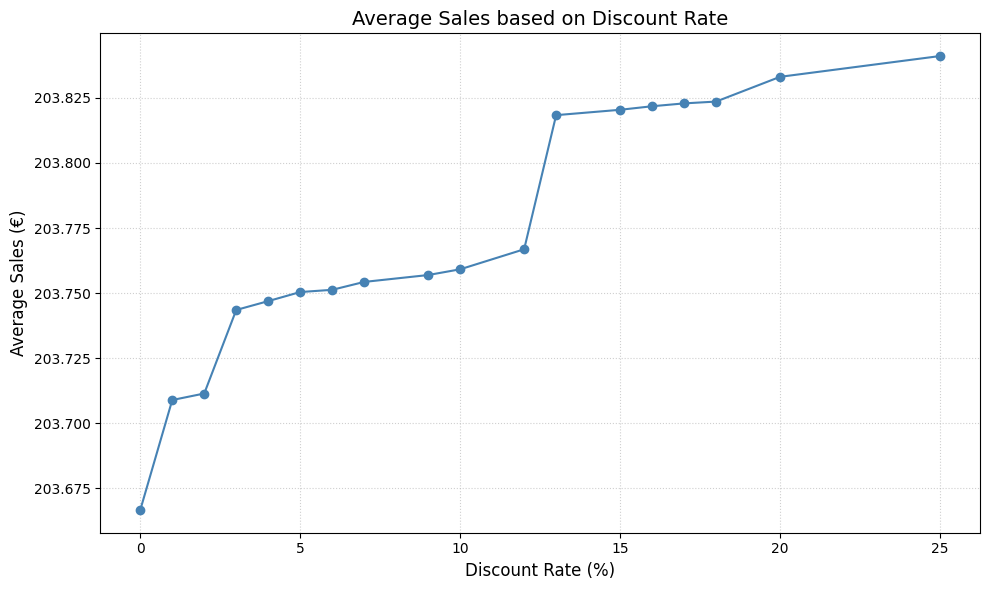

In [ ]:
# Aggregate Sales by Discount Rate
sales_discount_impact = df.groupby('Order Item Discount Rate').agg(
    Avg_Sales=('Sales', 'mean'),
    Total_Orders=('Order Id', 'count')
).reset_index().sort_values(by='Order Item Discount Rate')

# Create the Chart
plt.figure(figsize=(10, 6))
x_data = sales_discount_impact['Order Item Discount Rate'] * 100
y_data = sales_discount_impact['Avg_Sales']

plt.plot(x_data, y_data, marker='o', linestyle='-', color='steelblue')

plt.title('Average Sales based on Discount Rate', fontsize=14)
plt.xlabel('Discount Rate (%)', fontsize=12)
plt.ylabel('Average Sales (€)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('impact_remise_ventes.png')
plt.show()

### Visualize Profit Ratio vs. Discount Rate per Category

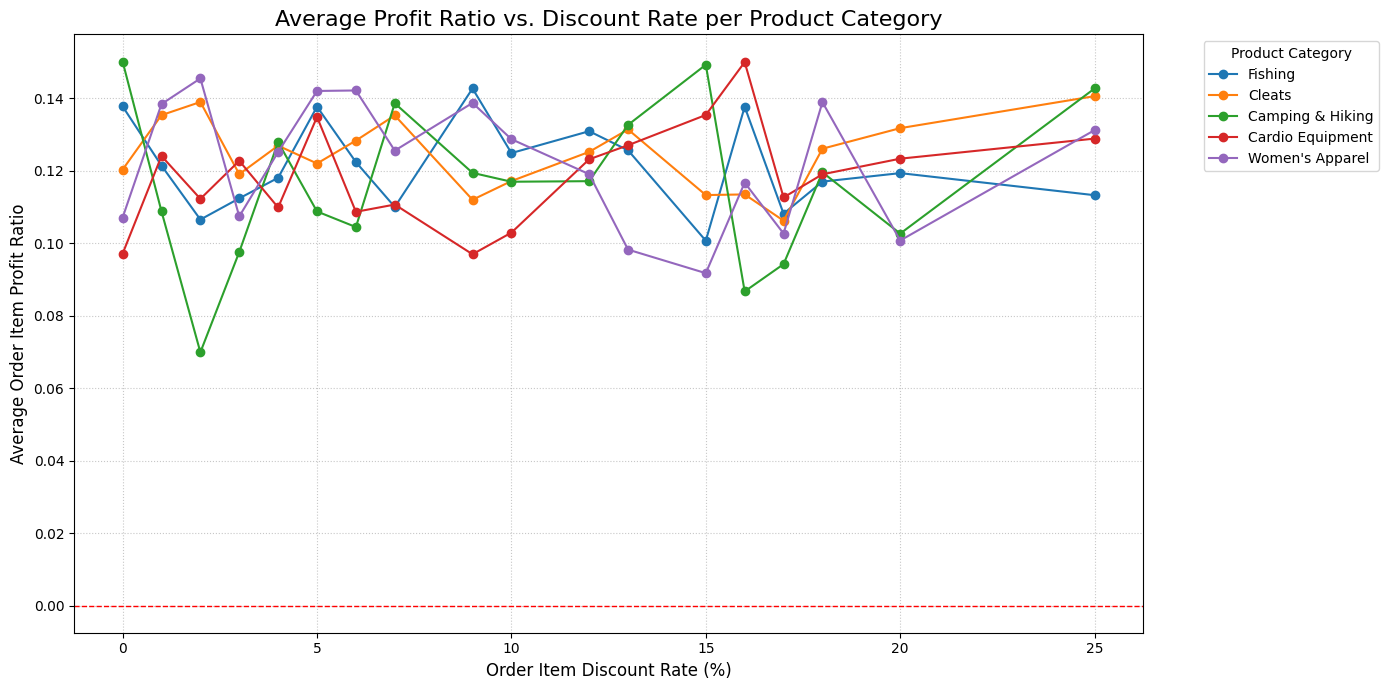

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Liste des catégories pour l'analyse (Retrait de 'Computers', Ajout de 'Camping & Hiking') ---
selected_categories = ['Fishing', 'Cleats', 'Camping & Hiking', 'Cardio Equipment', "Women's Apparel"]

df_filtered_categories = df[df['Category Name'].isin(selected_categories)].copy()

discount_impact_category = df_filtered_categories.groupby(
    ['Category Name', 'Order Item Discount Rate']
).agg(
    Avg_Sales=('Sales', 'mean'),
    Avg_Profit_Ratio=('Order Item Profit Ratio', 'mean')
).reset_index()

# --- Visualize Profit Ratio vs. Discount Rate per Category ---
plt.figure(figsize=(14, 7))

# Loop through each selected category to plot its profit ratio trend
for category in selected_categories:
    category_data = discount_impact_category[discount_impact_category['Category Name'] == category]

    # Vérification pour s'assurer qu'il y a des données à tracer
    if not category_data.empty:
        plt.plot(category_data['Order Item Discount Rate'] * 100,
                 category_data['Avg_Profit_Ratio'],
                 marker='o',
                 label=category)

plt.title('Average Profit Ratio vs. Discount Rate per Product Category', fontsize=16)
plt.xlabel('Order Item Discount Rate (%)', fontsize=12)
plt.ylabel('Average Order Item Profit Ratio', fontsize=12)

# Ligne de référence à 0 pour le seuil de profitabilité
plt.axhline(0, color='red', linestyle='--', linewidth=1)

plt.legend(title='Product Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig('profit_ratio_vs_discount_rate_by_category.png')
plt.show()

## **Linear Regression Analysis**

In [ ]:
# ================================================================
# SIMPLE LINEAR REGRESSION - SALES PER CUSTOMER
# ================================================================

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------
# 1. SELECT VARIABLES
# ------------------------------------------------

features = ["Product Group", "Customer Segment", "Distance_km"]
target = "Sales per customer"

# Remove missing rows
df_clean = df[features + [target]].dropna()

# Features and target
X = df_clean[features]
y = df_clean[target]

# ------------------------------------------------
# 2. DUMMIES FOR CATEGORICAL VARIABLES
# ------------------------------------------------

X = pd.get_dummies(X, drop_first=True)

# ------------------------------------------------
# 3. SCALE NUMERIC FEATURES (optional but recommended)
# ------------------------------------------------

numeric_cols = ["Distance_km"]
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# ------------------------------------------------
# 4. TRAIN/TEST SPLIT
# ------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------------------------
# 5. TRAIN LINEAR REGRESSION
# ------------------------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

# ------------------------------------------------
# 6. PREDICT
# ------------------------------------------------

y_pred = model.predict(X_test)

# ------------------------------------------------
# 7. EVALUATION
# ------------------------------------------------

mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("================================================")
print("LINEAR REGRESSION - SALES PER CUSTOMER")
print("================================================")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

# ------------------------------------------------
# 8. COEFFICIENTS
# ------------------------------------------------

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print("\n================ Coefficients ================")
print(coef_df.sort_values(by="Coefficient", ascending=False))

LINEAR REGRESSION - SALES PER CUSTOMER
R² Score: 0.7144
MSE: 4064.1092
RMSE: 63.7504

================ Coefficients ================
                               Feature  Coefficient
11               Customer Segment_High   220.340105
3                Product Group_Fishing    89.865532
10             Customer Segment_Medium    79.966209
1       Product Group_Cardio Equipment    70.646760
8           Product Group_Water Sports    50.516530
6          Product Group_Other Product    43.026232
5         Product Group_Men's Footwear    32.066060
7          Product Group_Shop By Sport    24.517120
2                 Product Group_Cleats    15.993944
4   Product Group_Indoor/Outdoor Games    13.404199
9        Product Group_Women's Apparel    13.340483
0                          Distance_km    -0.275287


In [ ]:
intercept = model.intercept_

print("Intercept:", intercept)

Intercept: 49.20066118675081
